# Phase 3 - Tone by Publisher Country Analysis
Analyzing the tone of the Olympics news coverage by country.

Variable:
- GDELT v2tone_raw

This variable is a score with six values:
- **Tone** (-100 to +100; but realistically -10 extremely negative, +10 extremely positive)
- PositiveScore
- NegativeScore
- Polarity
- ActivityReferenceDensity
- SelfGroupReferenceDensity**

Limitations: GDELT tone is:
- Dictionary-based
- Language-agnostic
- Not context-aware
- Sensitive to words like “attack,” “crisis,” etc.

So:
- It does not understand sarcasm.
- It does not understand context.
- It is not transformer-based sentiment.

In [2]:
import sys
!{sys.executable} -m pip install -q -U google-cloud-bigquery google-cloud-bigquery-storage pyarrow db-dtypes pandas-gbq

In [3]:
import tldextract
from urllib.parse import urlparse
from pathlib import Path
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [4]:
# load query data from repo

data_path = Path("../data/gdelt_gkg_feb2026_relevance_ladder_lvl3_mapped.parquet")
df = pd.read_parquet(data_path, engine="pyarrow")
# df["day"] = pd.to_datetime(df["day"])



df.shape

(30565, 24)

In [5]:
np.max(df.v2tone_raw)

'9.96732026143791,10.1307189542484,0.163398692810458,10.2941176470588,17.6470588235294,0,548'

In [6]:
np.min(df.v2tone_raw)

'-0.0591016548463359,2.77777777777778,2.83687943262411,5.61465721040189,17.612293144208,0.177304964539007,1421'

In [7]:
df.rel_strict.value_counts()

rel_strict
True     29542
False     1023
Name: count, dtype: Int64

### Setting Filters

Only include:
- countries with n_articles >= 100
- strict tier filter (rel_strict) with mentions of "olympics, milan, cortina etc."

In [9]:
# I will only focus on the strict tier where the olympics are specifically mentioned
strict_df = df[df["rel_strict"]].copy()

# I will only inlcude countries with >= 100 strict articles
country_counts = (
    strict_df["publisher_country_final"]
    .value_counts()
)

valid_countries = country_counts[country_counts >= 100].index

In [10]:
valid_countries

Index(['United States', 'Italy', 'France', 'United Kingdom', 'Spain', 'Mexico',
       'Canada', 'Australia', 'Japan', 'Turkey', 'Ireland', 'Malaysia'],
      dtype='object', name='publisher_country_final')

In [11]:
len(valid_countries)

12

In [12]:
# Article counts by country and average tone (using rel_strict criteria)
tone_stats = (
    strict_df
    .groupby("publisher_country_final")
    .agg(
        avg_tone=("tone", "mean"),
        article_count=("tone", "count")
    )
    .sort_values("article_count", ascending=False)
)

# Only include samples with >= 100 articles
tone_stats_filtered = tone_stats[tone_stats["article_count"] >= 100]
tone_stats_filtered.sort_values("avg_tone", ascending=False)

,avg_tone,article_count
publisher_country_final,,
Turkey,3.456683,130
Malaysia,2.364486,100
United Kingdom,2.228832,693
Italy,1.980412,8430
United States,1.746854,12481
Canada,1.656215,357
Ireland,1.195144,121
Japan,1.174959,146
Mexico,1.156091,362


In [13]:
tone_stats.loc["Germany"] # fell out of top 15, apparently too many articles without Olympics context

avg_tone          2.750774
article_count    66.000000
Name: Germany, dtype: float64

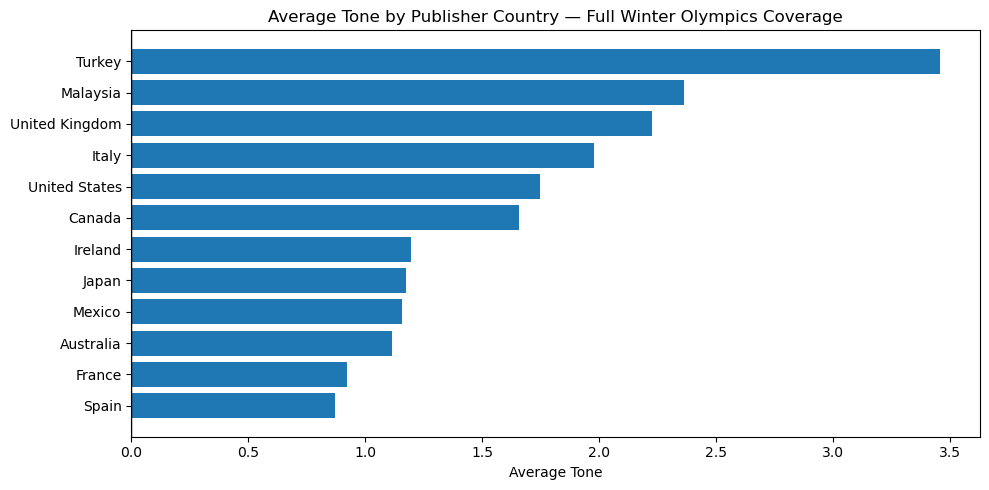

In [14]:
# Plot tone by country
top = tone_stats_filtered.sort_values("avg_tone")

plt.figure(figsize=(10,5))
plt.barh(top.index, top["avg_tone"])
plt.axvline(0, color="black", linewidth=1)
plt.title("Average Tone by Publisher Country — Full Winter Olympics Coverage")
plt.xlabel("Average Tone")
plt.tight_layout()
plt.show()

### Analysis of Before/During/After Olympics News Coverage Tone

In [16]:
before = strict_df[
    (strict_df["day"] < "2026-02-06") &
    (strict_df["publisher_country_final"].isin(valid_countries))
]

during = strict_df[
    (strict_df["day"] >= "2026-02-06") &
    (strict_df["day"] <= "2026-02-22") &
    (strict_df["publisher_country_final"].isin(valid_countries))
]

after = strict_df[
    (strict_df["day"] > "2026-02-22") &
    (strict_df["publisher_country_final"].isin(valid_countries))
]

In [17]:
before_stats = before.groupby("publisher_country_final")["tone"].mean()
during_stats = during.groupby("publisher_country_final")["tone"].mean()
after_stats  = after.groupby("publisher_country_final")["tone"].mean()

In [18]:
tone_period_df = pd.DataFrame({
    "before": before_stats,
    "during": during_stats,
    "after": after_stats
}).dropna()

tone_period_df

,before,during,after
publisher_country_final,,,
Australia,1.534943,0.758257,3.559377
Canada,1.113859,1.675662,2.476968
France,0.088634,0.954220,1.715295
Ireland,0.864419,0.674883,3.618422
Italy,1.492834,2.031764,2.863544
Japan,0.829261,0.896757,3.640593
Malaysia,1.469657,2.350585,3.933489
Mexico,1.158492,1.193410,0.561419
Spain,0.534853,0.852116,1.528504


In [19]:
# Include article count in each period
before_counts = before.groupby("publisher_country_final")["tone"].count()
during_counts = during.groupby("publisher_country_final")["tone"].count()
after_counts  = after.groupby("publisher_country_final")["tone"].count()

tone_period_df["n_before"] = before_counts
tone_period_df["n_during"] = during_counts
tone_period_df["n_after"]  = after_counts

tone_period_df

,before,during,after,n_before,n_during,n_after
publisher_country_final,,,,,,
Australia,1.534943,0.758257,3.559377,76,207,17
Canada,1.113859,1.675662,2.476968,58,267,32
France,0.088634,0.954220,1.715295,64,638,43
Ireland,0.864419,0.674883,3.618422,6,94,21
Italy,1.492834,2.031764,2.863544,1541,6411,478
Japan,0.829261,0.896757,3.640593,8,123,15
Malaysia,1.469657,2.350585,3.933489,11,82,7
Mexico,1.158492,1.193410,0.561419,43,300,19
Spain,0.534853,0.852116,1.528504,44,387,35


In [20]:
# Include delta calculations for tone
# Filter: at least 10 articles in EACH period
min_n = 10

# Add delta columns
tone_period_df["during_minus_before"] = tone_period_df["during"] - tone_period_df["before"]
tone_period_df["after_minus_during"]  = tone_period_df["after"]  - tone_period_df["during"]

tone_period_filtered = tone_period_df[
    (tone_period_df["n_before"] >= min_n) &
    (tone_period_df["n_during"] >= min_n) &
    (tone_period_df["n_after"] >= min_n)
].copy()

tone_period_filtered.sort_values("after_minus_during", ascending=False)

,before,during,after,n_before,n_during,n_after,during_minus_before,after_minus_during
publisher_country_final,,,,,,,,
Australia,1.534943,0.758257,3.559377,76,207,17,-0.776686,2.801119
Italy,1.492834,2.031764,2.863544,1541,6411,478,0.538930,0.831780
Canada,1.113859,1.675662,2.476968,58,267,32,0.561803,0.801306
France,0.088634,0.954220,1.715295,64,638,43,0.865585,0.761075
Spain,0.534853,0.852116,1.528504,44,387,35,0.317263,0.676388
United States,1.815183,1.702952,2.266435,2397,9589,495,-0.112231,0.563483
United Kingdom,0.333107,2.469264,2.304990,76,591,26,2.136157,-0.164274
Mexico,1.158492,1.193410,0.561419,43,300,19,0.034918,-0.631991


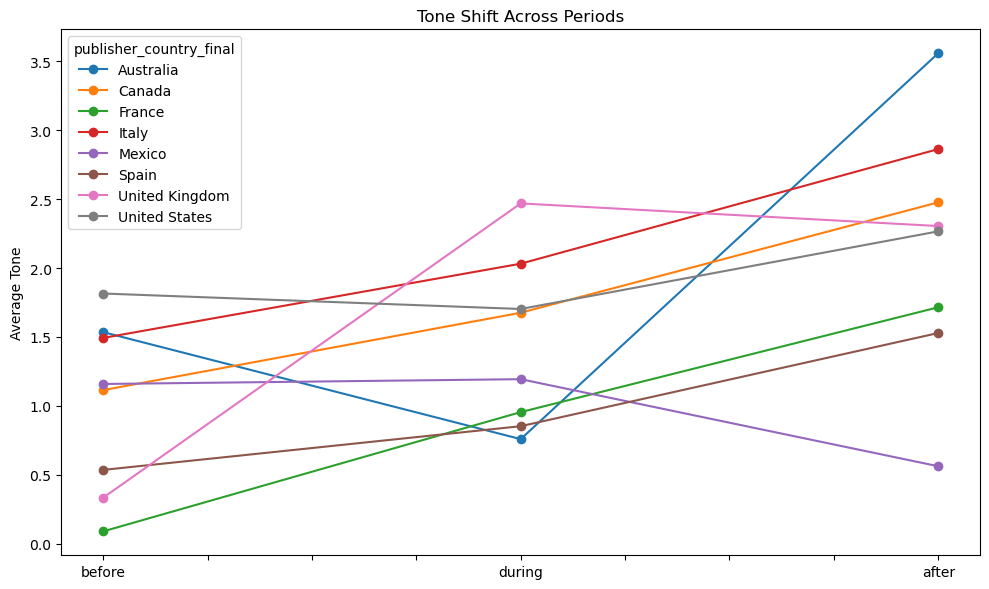

In [21]:
tone_period_filtered[["before", "during", "after"]].T.plot(
    figsize=(10,6),
    marker="o"
)

plt.title("Tone Shift Across Periods")
plt.ylabel("Average Tone")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Analysis of Tone by Country for all of February 2026

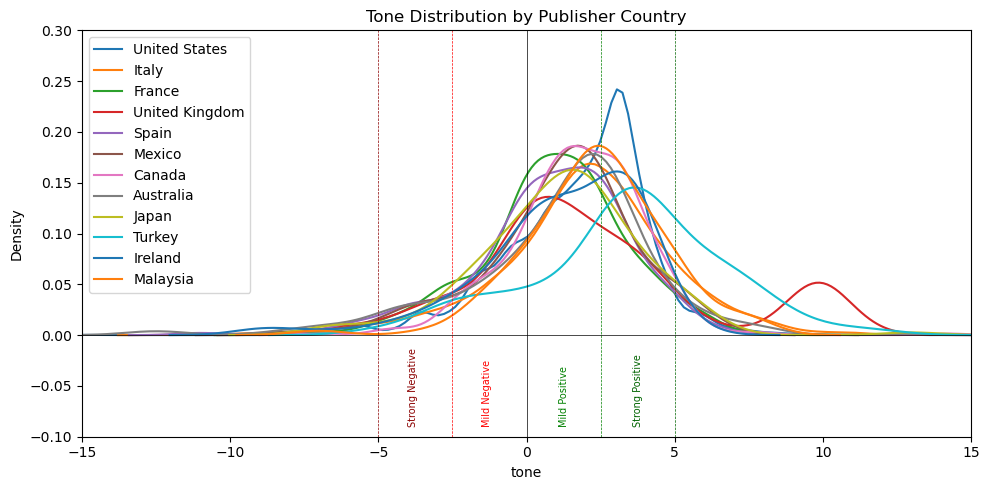

In [23]:
top_countries = tone_stats_filtered.head(15).index.tolist()

plt.figure(figsize=(10, 5))

for country in top_countries:
    sns.kdeplot(
        df[df["publisher_country_final"] == country]["tone"],
        label=country
    )
    
plt.ylim(-0.1,0.3)
plt.xlim(-15,15)

# Add interpretation lines
plt.axvline(-5, color="darkred", linestyle="--", linewidth=0.5)
plt.axvline(-2.5, color="red", linestyle="--", linewidth=0.5)
plt.axvline(0, color="black", linestyle="-", linewidth=0.5)
plt.axvline(2.5, color="green", linestyle="--", linewidth=0.5)
plt.axvline(5, color="darkgreen", linestyle="--", linewidth=0.5)
plt.axhline(0, color="black", linestyle="-", linewidth=0.5)

# Optional: add labels
plt.text(-4, plt.ylim()[1]*-0.3, "Strong Negative", rotation=90, va="bottom", color="darkred", size=7)
plt.text(-1.5, plt.ylim()[1]*-0.3, "Mild Negative", rotation=90, va="bottom", color="red", size=7)
# plt.text(1, plt.ylim()[1]*0.15, "Neutral", rotation=90, va="top", color="grey", size=8)
plt.text(1.1, plt.ylim()[1]*-0.3, "Mild Positive", rotation=90, va="bottom", color="green", size=7)
plt.text(3.6, plt.ylim()[1]*-0.3, "Strong Positive", rotation=90, va="bottom", color="darkgreen", size=7)


plt.title("Tone Distribution by Publisher Country")
plt.legend()
plt.tight_layout()
plt.show()

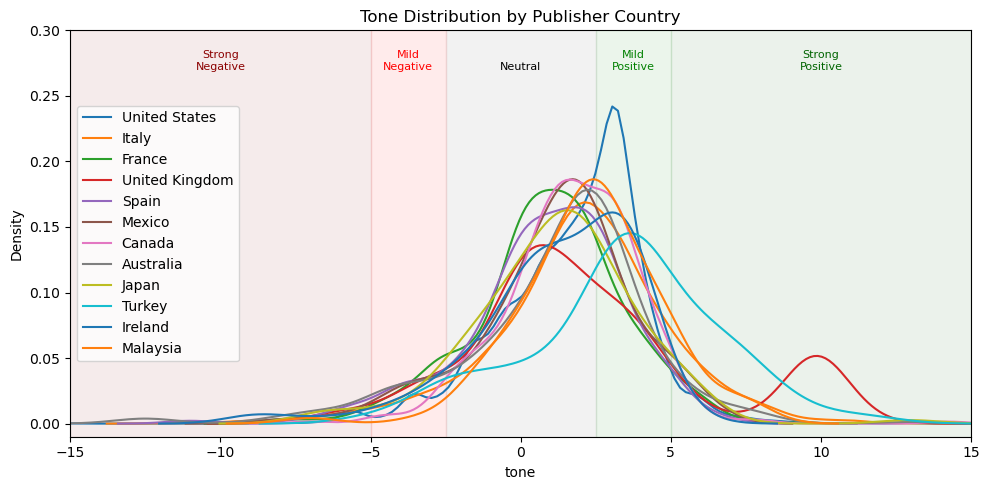

In [24]:
top_countries = tone_stats_filtered.head(15).index.tolist()

plt.figure(figsize=(10, 5))

# === SHADED REGIONS ===
xmin, xmax = -15, 15

# Strong negative
plt.axvspan(xmin, -5, color="darkred", alpha=0.08)

# Mild negative
plt.axvspan(-5, -2.5, color="red", alpha=0.08)

# Neutral
plt.axvspan(-2.5, 2.5, color="grey", alpha=0.10)

# Mild positive
plt.axvspan(2.5, 5, color="green", alpha=0.08)

# Strong positive
plt.axvspan(5, xmax, color="darkgreen", alpha=0.08)

# === KDE PLOTS ===
for country in top_countries:
    sns.kdeplot(
        df[df["publisher_country_final"] == country]["tone"],
        label=country
    )

plt.xlim(xmin, xmax)
plt.ylim(-0.01, 0.3)

# Optional: labels centered in regions
plt.text(-10, 0.27, "Strong\nNegative", color="darkred", ha="center", size=8)
plt.text(-3.75, 0.27, "Mild\nNegative", color="red", ha="center", size=8)
plt.text(0, 0.27, "Neutral", color="black", ha="center", size=8)
plt.text(3.75, 0.27, "Mild\nPositive", color="green", ha="center", size=8)
plt.text(10, 0.27, "Strong\nPositive", color="darkgreen", ha="center", size=8)

plt.title("Tone Distribution by Publisher Country")
plt.legend()
plt.tight_layout()
plt.show()

### Tone Band per Country Analysis

In [26]:
def tone_band(t):
    if pd.isna(t):
        return "Unknown"
    if t < -5:
        return "Strong Negative"
    elif t < -2.5:
        return "Mild Negative"
    elif t <= 2.5:
        return "Neutral"
    elif t <= 5:
        return "Mild Positive"
    else:
        return "Strong Positive"

df["tone_band"] = df["tone"].apply(tone_band)

In [27]:
# Filter to relevant countries by minimum volume (100 articles)

band_distribution = (
    df[df["publisher_country_final"].isin(top_countries)]
    .groupby(["publisher_country_final", "tone_band"])
    .size()
    .unstack(fill_value=0)
)

band_percent = band_distribution.div(band_distribution.sum(axis=1), axis=0) * 100

band_percent.round(2)

tone_band,Mild Negative,Mild Positive,Neutral,Strong Negative,Strong Positive
publisher_country_final,,,,,
Australia,7.57,32.24,48.68,4.61,6.91
Canada,3.32,35.29,58.31,0.26,2.81
France,8.50,19.22,66.41,1.70,4.18
Ireland,4.92,39.34,51.64,3.28,0.82
Italy,4.75,30.55,49.40,2.44,12.86
Japan,4.70,20.81,65.77,2.68,6.04
Malaysia,0.98,36.27,51.96,0.98,9.80
Mexico,7.65,22.68,60.93,2.46,6.28
Spain,7.64,23.35,62.81,3.10,3.10


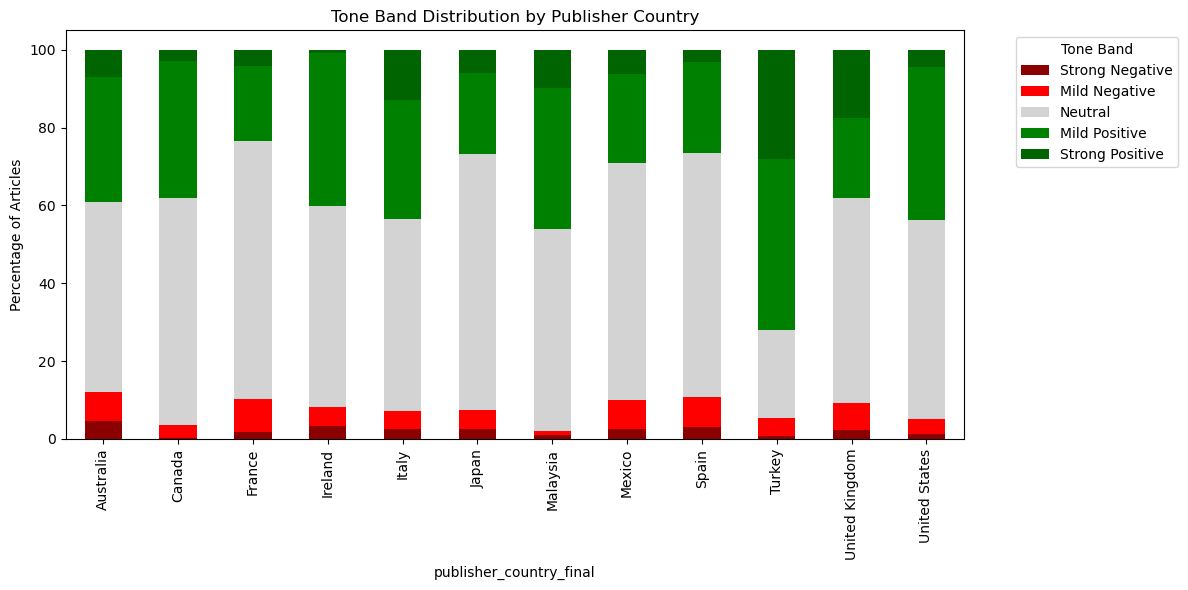

In [28]:
tone_order = [
    "Strong Negative",
    "Mild Negative",
    "Neutral",
    "Mild Positive",
    "Strong Positive"
]

custom_colors = {
    "Strong Negative": "darkred",
    "Mild Negative": "red",
    "Neutral": "lightgrey",
    "Mild Positive": "green",
    "Strong Positive": "darkgreen"
}

# Ensure consistent column order
for band in tone_order:
    if band not in band_percent.columns:
        band_percent[band] = 0

band_percent = band_percent[tone_order]

ax = band_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    color=[custom_colors[c] for c in tone_order]
)

plt.title("Tone Band Distribution by Publisher Country")
plt.ylabel("Percentage of Articles")
plt.legend(title="Tone Band", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [29]:
# Investigate UK outlier articles
uk_extreme_pos = (
    df[df["publisher_country_final"] == "United Kingdom"]
    .sort_values("tone")
    [["day", "tone", "url"]]
    .head(10)
)

uk_extreme_pos

,day,tone,url
13718,2026-02-12,-7.232704,https://www.aol.co.uk/articles/ukrainian-disqu...
8056,2026-02-17,-6.984668,https://www.ibtimes.co.uk/winter-olympics-2026...
2982,2026-02-08,-6.865672,https://www.independent.co.uk/news/world/europ...
13151,2026-02-08,-6.784141,https://www.dailymail.co.uk/news/article-15539...
23191,2026-02-16,-6.713781,https://news.sky.com/story/winter-olympics-liv...
1241,2026-02-07,-6.116208,https://www.express.co.uk/news/world/2168163/w...
13997,2026-02-16,-6.000000,https://news.sky.com/story/winter-olympics-as-...
25074,2026-02-09,-5.760000,https://www.thisisoxfordshire.co.uk/news/25830...
25090,2026-02-09,-5.760000,https://www.oxfordmail.co.uk/news/25830013.dri...
29509,2026-02-09,-5.760000,https://www.heraldseries.co.uk/news/25830013.d...


In [30]:
# Investigate Tukey outlier articles
turkey_extreme_pos = (
    df[df["publisher_country_final"] == "Turkey"]
    .sort_values("tone")
    [["day", "tone", "url"]]
    .head(10)
)

turkey_extreme_pos

,day,tone,url
19266,2026-02-05,-5.063291,https://www.evrensel.net/haber/5969265/ogrenci...
26558,2026-02-05,-4.545455,https://www.haberler.com/spor/2026-milano-cort...
1167,2026-02-07,-3.243243,https://www.haberler.com/guncel/milano-cortina...
5620,2026-02-07,-3.243243,http://www.haberler.com/guncel/milano-cortina-...
14493,2026-02-06,-2.564103,http://www.haberler.com/spor/2026-milano-corti...
14448,2026-02-06,-2.564103,https://www.haberler.com/spor/2026-milano-cort...
7899,2026-02-07,-2.507837,https://www.evrensel.net/haber/5969461/milano-...
29864,2026-02-06,-2.400000,https://www.aa.com.tr/tr/dunya/italyada-milano...
19511,2026-02-05,-2.380952,http://www.haberler.com/spor/milano-cortina-ki...
19515,2026-02-05,-2.380952,https://www.haberler.com/spor/milano-cortina-k...


### Statistical Analysis of Tone by Country (Variance)

In [32]:
# Tone Variance
tone_stats_extended = (
    df[df["rel_strict"]]
    .groupby("publisher_country_final")
    .agg(
        avg_tone=("tone", "mean"),
        std_tone=("tone", "std"),
        article_count=("tone", "count")
    )
    .sort_values("article_count", ascending=False)
)

tone_stats_extended.head(15)

,avg_tone,std_tone,article_count
publisher_country_final,,,
United States,1.746854,2.477710,12481
Italy,1.980412,3.023203,8430
France,0.923788,2.499884,745
United Kingdom,2.228832,3.962826,693
Spain,0.872961,2.630478,466
Mexico,1.156091,2.592752,362
Canada,1.656215,2.230375,357
Australia,1.113748,3.238216,300
Japan,1.174959,2.743006,146


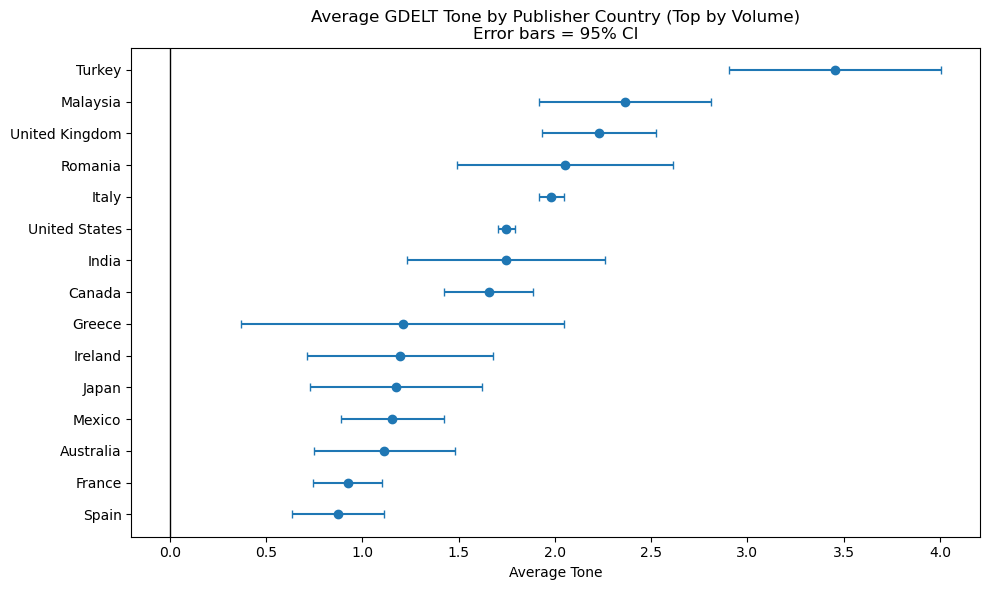

In [33]:
# choose top countries by volume
top_n = 15
plot_df = tone_stats_extended.head(top_n).copy()

# 95% CI using normal approx: mean ± 1.96 * (std / sqrt(n))
plot_df["se"] = plot_df["std_tone"] / np.sqrt(plot_df["article_count"])
plot_df["ci95"] = 1.96 * plot_df["se"]

# sort by mean tone for nicer plotting
plot_df = plot_df.sort_values("avg_tone")

plt.figure(figsize=(10, 6))
plt.errorbar(
    x=plot_df["avg_tone"],
    y=plot_df.index,
    xerr=plot_df["ci95"],
    fmt="o",
    capsize=3
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Average GDELT Tone by Publisher Country (Top by Volume)\nError bars = 95% CI")
plt.xlabel("Average Tone")
plt.ylabel("")
plt.tight_layout()
plt.show()

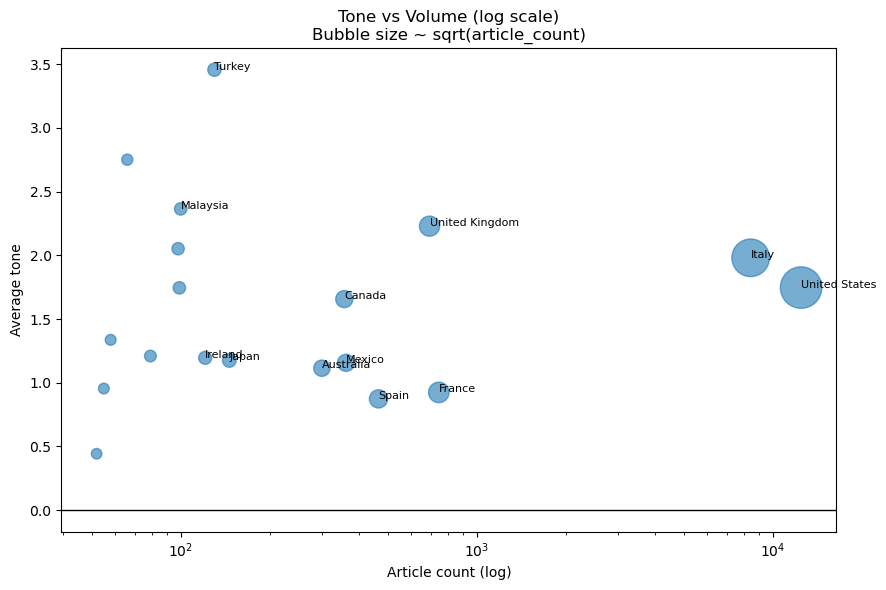

In [34]:
plot_df2 = tone_stats_extended.copy()
plot_df2 = plot_df2[plot_df2["article_count"] >= 50].copy()  # filter small-N noise

plt.figure(figsize=(9, 6))
plt.scatter(
    plot_df2["article_count"],
    plot_df2["avg_tone"],
    s=np.sqrt(plot_df2["article_count"]) * 8,  # bubble scaling
    alpha=0.6
)

for country, row in plot_df2.head(12).iterrows():  # label top 12 by count
    plt.text(row["article_count"], row["avg_tone"], country, fontsize=8)

plt.axhline(0, color="black", linewidth=1)
plt.xscale("log")
plt.title("Tone vs Volume (log scale)\nBubble size ~ sqrt(article_count)")
plt.xlabel("Article count (log)")
plt.ylabel("Average tone")
plt.tight_layout()
plt.show()